# Ride-Sharing Demand & Revenue Intelligence  
## Stage 1: Exploratory Data Analysis (SQL + Python)

### Objective

Analyze demand patterns, revenue distribution, and behavioral trends 
using SQL for aggregations and Python for visualization

In [5]:
import duckdb 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv(r'C:\prerit\Projects\Ride-Sharing-Demand-Intelligence\Processed\Cleaned_yellow_tripdata_2025-01.csv')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee,trip_duration_min,pickup_hour,pickup_day,pickup_weekday,is_weekend,revenue_per_mile,revenue_per_minute,tip_percentage
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,0.0,8.35,0,1,2,0,11.25,2.16,0.30
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,0.0,2.55,0,1,2,0,24.24,4.75,0.40
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,0.0,1.95,0,1,2,0,20.17,6.21,0.39
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,5.57,0,1,2,0,18.65,1.74,0.00
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,3.53,0,1,2,0,12.58,2.35,0.00


### Let's stablish connection for SQL

In [7]:
connection = duckdb.connect()
connection.register("taxi", df)

### Hourly demand analysis using SQL

In [9]:
query = """
select 
  pickup_hour,
  count(*) as total_trips,
  round(sum(total_amount), 2) as total_revenue,
  round(avg(fare_amount), 2) as avg_fare,
  round(avg(tip_amount), 2) as avg_tip,
  round(avg(trip_duration_min), 2) as avg_trip_duration
from taxi
group by pickup_hour
order by pickup_hour
"""

hourly_df = connection.execute(query).df()

hourly_df.head()

,pickup_hour,total_trips,total_revenue,avg_fare,avg_tip,avg_trip_duration
0,0,83389,2170044.30,17.65,2.69,13.62
1,1,57518,1407829.73,16.56,2.45,12.90
2,2,38855,913749.36,15.84,2.31,12.64
3,3,24442,591407.57,16.44,2.36,12.56
4,4,16860,486334.28,20.58,2.66,14.12


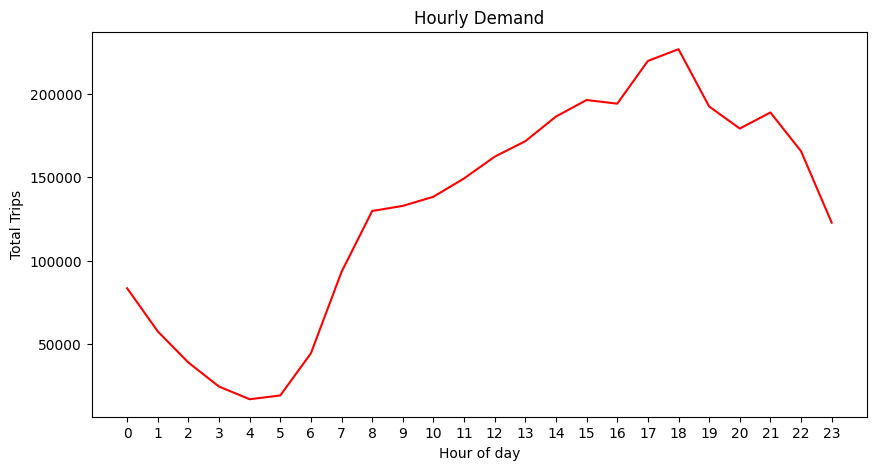

In [31]:
plt.figure(figsize=(10,5))
sns.lineplot( x="pickup_hour", y="total_trips", data=hourly_df, color="red") # line plot using seaborn
# plt.plot(hourly_df["pickup_hour"], hourly_df["total_trips"], color="red") # line plot using matplotlib.pyplot
# plt.bar(hourly_df["pickup_hour"], hourly_df["total_trips"], color="red") # bar plot using matplotlib.pyplot
plt.title("Hourly Demand")
plt.xlabel("Hour of day")
plt.ylabel("Total Trips")
plt.xticks(range(0,24))
plt.show()